# IY013 -- Pairwise (one-vs-one) Classification Results: 6-class old dataset

**Goal:** Visualise the pairwise Raw SVM / LSTM / Transformer sweep produced by
`IY013_tf_condition_pairwise_old.py` (all 15 pairs of the 6 fixed old-dataset classes
-- Nrg1/Rtg1 x 3 glucose conditions -- on both Steady-state and Full variants).

This notebook only loads and plots `IY013_tf_condition_pairwise_old_results.csv`; it
does not retrain anything. Run `IY013_tf_condition_pairwise_old.py` first (it is
resumable, so it is safe to leave running via e.g. `nohup`).

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

IY013_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY013")

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
sys.path.insert(0, str(IY013_DIR))
from IY013_pairwise_heatmaps import plot_pairwise_heatmaps, plot_pairwise_summary

plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

In [2]:
RESULTS_CSV = IY013_DIR / "IY013_tf_condition_pairwise_old_results.csv"
results_df = pd.read_csv(RESULTS_CSV)

# Fixed 6-class selection: Nrg1 and Rtg1 at the 3 glucose conditions used in IY021
# (same order as IY013_tf_condition_pairwise_old.py; sorted for canonical matrix indexing)
CLASSES = sorted([
    "Nrg1 @ 0.01% glucose",
    "Nrg1 @ 0.1% glucose",
    "Nrg1 @ 2% glucose (mock/steady)",
    "Rtg1 @ 0.01% glucose",
    "Rtg1 @ 0.1% glucose",
    "Rtg1 @ 2% glucose (mock/steady)",
])
VARIANTS = ["Steady-state", "Full"]
CLASSIFIERS = ["Raw SVM", "LSTM", "Transformer"]

n_pairs_expected = len(CLASSES) * (len(CLASSES) - 1) // 2
n_expected = n_pairs_expected * len(VARIANTS) * len(CLASSIFIERS)
print(f"Loaded {len(results_df)} / {n_expected} expected rows "
      f"({n_pairs_expected} pairs x {len(VARIANTS)} variants x {len(CLASSIFIERS)} classifiers)")
results_df.head()

Loaded 90 / 90 expected rows (15 pairs x 2 variants x 3 classifiers)


,Class_A,Class_B,Dataset,Classifier,Accuracy,N_train,N_test
0,Nrg1 @ 0.01% glucose,Nrg1 @ 0.1% glucose,Steady-state,Raw SVM,0.946237,369,93
1,Nrg1 @ 0.01% glucose,Nrg1 @ 0.1% glucose,Steady-state,LSTM,0.956989,369,93
2,Nrg1 @ 0.01% glucose,Nrg1 @ 0.1% glucose,Steady-state,Transformer,0.946237,369,93
3,Nrg1 @ 0.01% glucose,Nrg1 @ 0.1% glucose,Full,Raw SVM,0.978495,369,93
4,Nrg1 @ 0.01% glucose,Nrg1 @ 0.1% glucose,Full,LSTM,0.978495,369,93


## Pairwise accuracy heatmaps

One heatmap per (dataset variant, classifier); cell = held-out test accuracy for that
class pair. Diagonal is masked (no self-pair). Chance level for every pair is 0.5.

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-25-IY013/IY013_tf_condition_pairwise_old_heatmaps.png


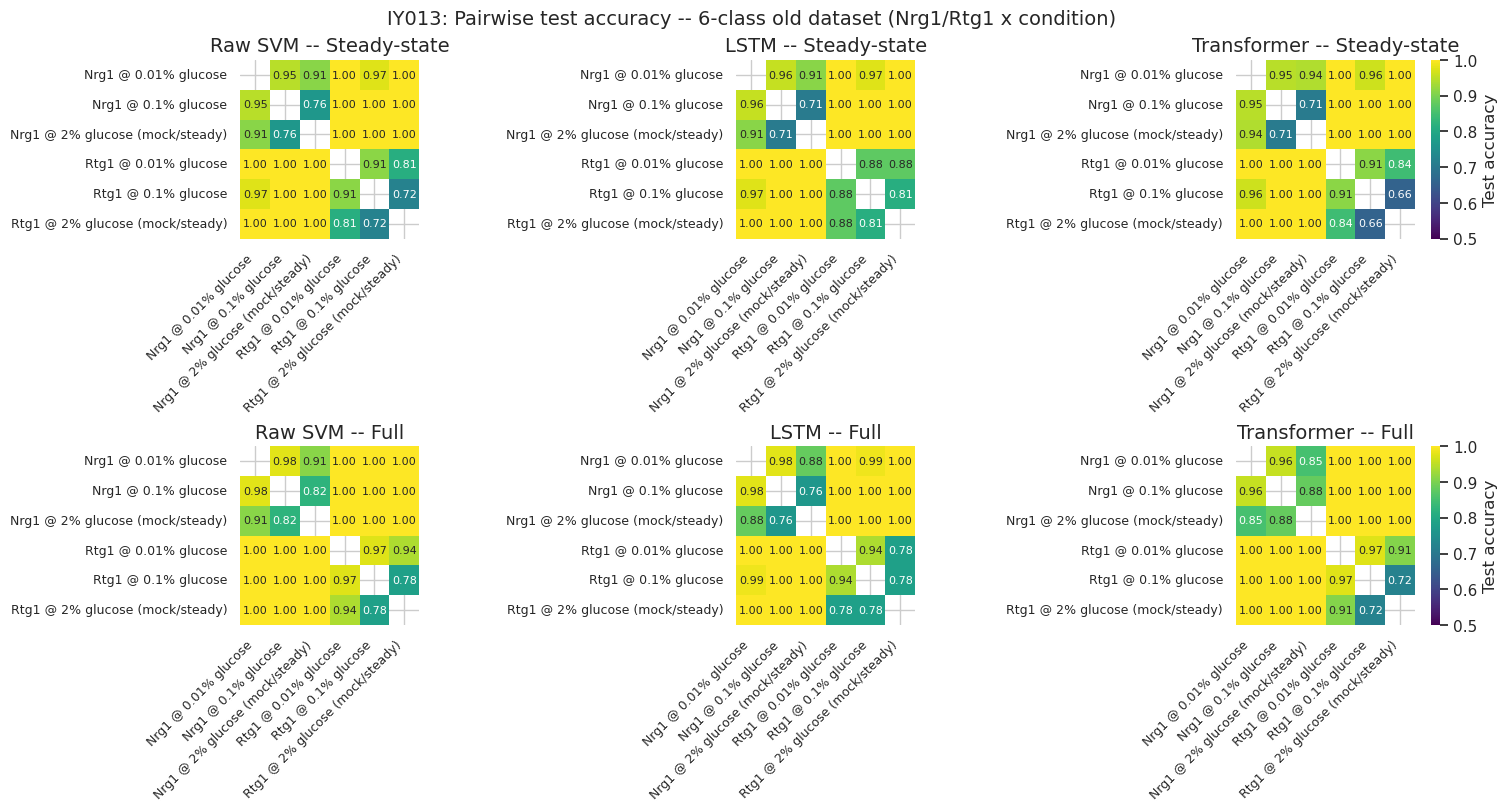

In [3]:
fig_path = IY013_DIR / "IY013_tf_condition_pairwise_old_heatmaps.png"
_ = plot_pairwise_heatmaps(
    results_df, CLASSES, VARIANTS, CLASSIFIERS,
    title="IY013: Pairwise test accuracy -- 6-class old dataset (Nrg1/Rtg1 x condition)",
    fig_path=fig_path, annot_fontsize=8,
)
plt.show()

## Summary: mean pairwise accuracy per classifier

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-25-IY013/IY013_tf_condition_pairwise_old_summary.png


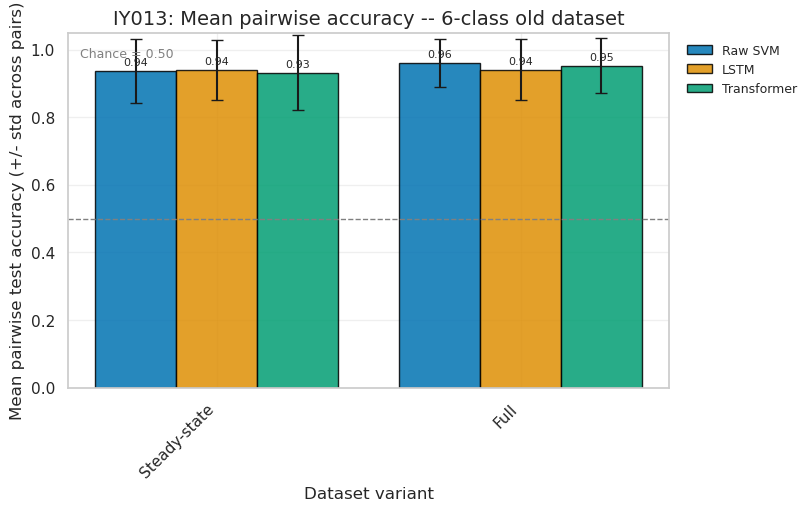

In [4]:
fig_path = IY013_DIR / "IY013_tf_condition_pairwise_old_summary.png"
_ = plot_pairwise_summary(
    results_df, VARIANTS, CLASSIFIERS,
    title="IY013: Mean pairwise accuracy -- 6-class old dataset",
    fig_path=fig_path,
)
plt.show()

## Hardest-to-distinguish pairs

Lowest mean accuracy (averaged across the 3 classifiers) per (variant, pair) --
i.e. the class pairs that are most confusable.

In [5]:
pair_means = (
    results_df.groupby(["Dataset", "Class_A", "Class_B"])["Accuracy"]
    .mean()
    .reset_index()
    .sort_values("Accuracy")
)
pair_means.head(10)

,Dataset,Class_A,Class_B,Accuracy
20,Steady-state,Nrg1 @ 0.1% glucose,Nrg1 @ 2% glucose (mock/steady),0.725490
29,Steady-state,Rtg1 @ 0.1% glucose,Rtg1 @ 2% glucose (mock/steady),0.729167
14,Full,Rtg1 @ 0.1% glucose,Rtg1 @ 2% glucose (mock/steady),0.760417
5,Full,Nrg1 @ 0.1% glucose,Nrg1 @ 2% glucose (mock/steady),0.823529
28,Steady-state,Rtg1 @ 0.01% glucose,Rtg1 @ 2% glucose (mock/steady),0.843750
13,Full,Rtg1 @ 0.01% glucose,Rtg1 @ 2% glucose (mock/steady),0.875000
1,Full,Nrg1 @ 0.01% glucose,Nrg1 @ 2% glucose (mock/steady),0.882353
27,Steady-state,Rtg1 @ 0.01% glucose,Rtg1 @ 0.1% glucose,0.900000
16,Steady-state,Nrg1 @ 0.01% glucose,Nrg1 @ 2% glucose (mock/steady),0.921569
15,Steady-state,Nrg1 @ 0.01% glucose,Nrg1 @ 0.1% glucose,0.949821
